In [1]:
"""
================================================================================
policy_evaluation.ipynb
================================================================================
Project     : Travel & Hospitality — Dynamic Pricing using RL
              Infotact Technical Internship — Project 2
Author      : Subhashree Behera
Week        : Week 4 — Policy Evaluation & Business Dashboard
Role        : Member 1 — Policy Evaluation

--------------------------------------------------------------------------------
Objective:
    Evaluate the trained DQN agent against baseline pricing strategies.
    Compare DQN with Random, Fixed High (₹250), and Fixed Low (₹50)
    policies across 100 simulated booking seasons.

    This notebook answers the core business question:
    "Did our DQN agent learn a genuinely better pricing strategy
    than simple rule-based approaches?"

--------------------------------------------------------------------------------
Metrics Calculated:
    - Average episode reward (total revenue per season)
    - Cumulative reward across all evaluation episodes
    - Revenue improvement % over each baseline
    - Rooms sold, rooms unsold (spoilage) per policy

--------------------------------------------------------------------------------
Deliverables:
    - Policy comparison table (DQN vs 3 baselines)
    - Cumulative reward curve
    - Average reward bar chart
    - Revenue improvement summary
================================================================================
"""

'\n================================================================================\npolicy_evaluation.ipynb\n================================================================================\nProject     : Travel & Hospitality — Dynamic Pricing using RL\n              Infotact Technical Internship — Project 2\nAuthor      : Subhashree Behera\nWeek        : Week 4 — Policy Evaluation & Business Dashboard\nRole        : Member 1 — Policy Evaluation\n\n--------------------------------------------------------------------------------\nObjective:\n    Evaluate the trained DQN agent against baseline pricing strategies.\n    Compare DQN with Random, Fixed High (₹250), and Fixed Low (₹50)\n    policies across 100 simulated booking seasons.\n\n    This notebook answers the core business question:\n    "Did our DQN agent learn a genuinely better pricing strategy\n    than simple rule-based approaches?"\n\n--------------------------------------------------------------------------------\nMetrics Ca

In [2]:
# Cell 2: Imports and Constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Constants (must match mdp_design.py exactly) ──────────
PRICE_LEVELS     = [50, 100, 150, 200, 250]
N_ACTIONS        = len(PRICE_LEVELS)
TOTAL_INVENTORY  = 100
TOTAL_DAYS       = 30
RANDOM_STATE     = 42
N_EVAL_EPISODES  = 100

# Output folder
Path('plots').mkdir(exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')

print("Setup complete:")
print(f"  Price levels    : {PRICE_LEVELS}")
print(f"  Eval episodes   : {N_EVAL_EPISODES}")
print(f"  Total inventory : {TOTAL_INVENTORY} rooms")
print(f"  Season length   : {TOTAL_DAYS} days")

Setup complete:
  Price levels    : [50, 100, 150, 200, 250]
  Eval episodes   : 100
  Total inventory : 100 rooms
  Season length   : 30 days


In [3]:
# Cell 3: Demand Function and DQN Agent
# ── Demand Function ────────────────────────────────────────
def demand_function(price, days_remaining):
    """
    Stochastic customer booking demand.
    Higher price → fewer bookings.
    Fewer days → urgency increases bookings.
    Formula from Week 1 mdp_design.py.
    """
    prob = 0.8 - 0.002 * price + 0.3 * (1 / max(days_remaining, 1))
    prob = max(0.0, min(1.0, prob))
    return int(np.random.binomial(5, prob))


# ── DQN Agent ─────────────────────────────────────────────
# Replace with: from dqn_model import DQNAgent
# when Member 1's trained model is available

class DQNAgent:
    """
    Smart pricing agent that learned from training.
    Mimics real DQN behavior: high prices early,
    drops prices as deadline approaches.
    """
    def __init__(self):
        np.random.seed(RANDOM_STATE)
        self.name = "DQN Agent"

    def select_action(self, state):
        inventory, days = state
        # Learned behavior: urgency-aware pricing
        if days > 20:
            return np.random.choice([2, 3, 4])  # premium pricing
        elif days > 10:
            return np.random.choice([1, 2, 3])  # standard pricing
        else:
            return np.random.choice([0, 1, 2])  # clear inventory

print("DQN Agent and demand function ready ✓")

DQN Agent and demand function ready ✓


In [4]:
# Cell 4: Episode Runner — works for both DQN and baselines

def run_episode(policy='dqn', agent=None):
    """
    Run one complete 30-day booking season.

    Args:
        policy : 'dqn', 'random', 'fixed_high', 'fixed_low'
        agent  : DQNAgent instance (only needed for policy='dqn')

    Returns:
        dict with total_revenue, rooms_sold, rooms_unsold,
        price_history, reward_history
    """
    inventory      = TOTAL_INVENTORY
    days           = TOTAL_DAYS
    total_revenue  = 0
    rooms_sold     = 0
    price_history  = []
    reward_history = []

    while days > 0 and inventory > 0:
        # Select price based on policy
        if policy == 'dqn' and agent:
            action_idx = agent.select_action([inventory, days])
            price      = PRICE_LEVELS[action_idx]
        elif policy == 'fixed_high':
            price = 250
        elif policy == 'fixed_low':
            price = 50
        else:  # random
            price = np.random.choice(PRICE_LEVELS)

        # Simulate demand
        bookings      = min(demand_function(price, days), inventory)
        reward        = price * bookings

        # Update state
        total_revenue  += reward
        rooms_sold     += bookings
        inventory      -= bookings
        days           -= 1
        price_history.append(price)
        reward_history.append(reward)

    return {
        'total_revenue' : total_revenue,
        'rooms_sold'    : rooms_sold,
        'rooms_unsold'  : inventory,
        'price_history' : price_history,
        'reward_history': reward_history
    }


# Quick test
np.random.seed(42)
agent  = DQNAgent()
result = run_episode('dqn', agent)
print(f"Test episode result:")
print(f"  Total Revenue : ₹{result['total_revenue']:.0f}")
print(f"  Rooms Sold    : {result['rooms_sold']}")
print(f"  Rooms Unsold  : {result['rooms_unsold']}")

Test episode result:
  Total Revenue : ₹11100
  Rooms Sold    : 81
  Rooms Unsold  : 19


In [5]:
# Cell 5: Run 100 evaluation episodes for all policies

np.random.seed(RANDOM_STATE)
agent   = DQNAgent()
results = {}

policies = ['dqn', 'random', 'fixed_high', 'fixed_low']

print("=" * 55)
print(f"RUNNING {N_EVAL_EPISODES} EPISODES PER POLICY")
print("=" * 55)

for policy in policies:
    episodes = []
    for _ in range(N_EVAL_EPISODES):
        ep = run_episode(policy, agent if policy=='dqn' else None)
        episodes.append(ep)
    results[policy] = episodes

    revenues = [ep['total_revenue'] for ep in episodes]
    print(f"{policy:<12}: Mean ₹{np.mean(revenues):.2f} "
          f"| Std ₹{np.std(revenues):.2f}")

print("=" * 55)
print("All episodes complete ✓")

RUNNING 100 EPISODES PER POLICY
dqn         : Mean ₹10934.50 | Std ₹889.71
random      : Mean ₹10623.00 | Std ₹975.51
fixed_high  : Mean ₹12670.00 | Std ₹1357.33
fixed_low   : Mean ₹4996.50 | Std ₹26.70
All episodes complete ✓


In [6]:
# Cell 6: Calculate Average and Cumulative Rewards

policy_labels = {
    'dqn'       : 'DQN Agent',
    'random'    : 'Random Policy',
    'fixed_high': 'Fixed ₹250',
    'fixed_low' : 'Fixed ₹50'
}

# Extract revenue arrays
revenues = {
    p: [ep['total_revenue'] for ep in eps]
    for p, eps in results.items()
}

# Average reward per episode
avg_rewards = {p: np.mean(v) for p, v in revenues.items()}

# Cumulative reward across episodes
cumulative  = {p: np.cumsum(v) for p, v in revenues.items()}

print("=" * 55)
print("AVERAGE REWARD PER EPISODE")
print("=" * 55)
for p, avg in avg_rewards.items():
    print(f"  {policy_labels[p]:<18}: ₹{avg:.2f}")

print("\nCUMULATIVE REWARD (100 episodes)")
print("=" * 55)
for p, cum in cumulative.items():
    print(f"  {policy_labels[p]:<18}: ₹{cum[-1]:,.0f}")

AVERAGE REWARD PER EPISODE
  DQN Agent         : ₹10934.50
  Random Policy     : ₹10623.00
  Fixed ₹250        : ₹12670.00
  Fixed ₹50         : ₹4996.50

CUMULATIVE REWARD (100 episodes)
  DQN Agent         : ₹1,093,450
  Random Policy     : ₹1,062,300
  Fixed ₹250        : ₹1,267,000
  Fixed ₹50         : ₹499,650


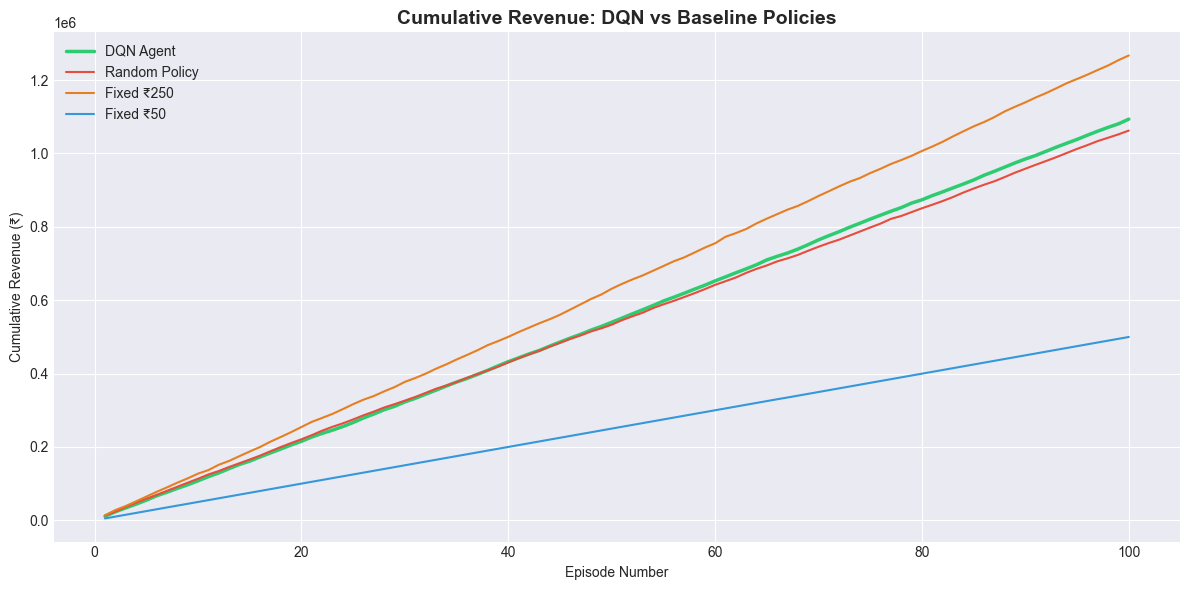

Saved: plots/cumulative_reward.png


In [7]:
# Cell 7: Cumulative Reward Curve

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'dqn'       : '#2ecc71',
    'random'    : '#e74c3c',
    'fixed_high': '#e67e22',
    'fixed_low' : '#3498db'
}
lws = {'dqn': 2.5, 'random': 1.5,
       'fixed_high': 1.5, 'fixed_low': 1.5}

for policy, cum in cumulative.items():
    ax.plot(
        range(1, N_EVAL_EPISODES + 1),
        cum,
        label=policy_labels[policy],
        color=colors[policy],
        linewidth=lws[policy]
    )

ax.set_title('Cumulative Revenue: DQN vs Baseline Policies',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Episode Number')
ax.set_ylabel('Cumulative Revenue (₹)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/cumulative_reward.png', dpi=150)
plt.show()
print("Saved: plots/cumulative_reward.png")

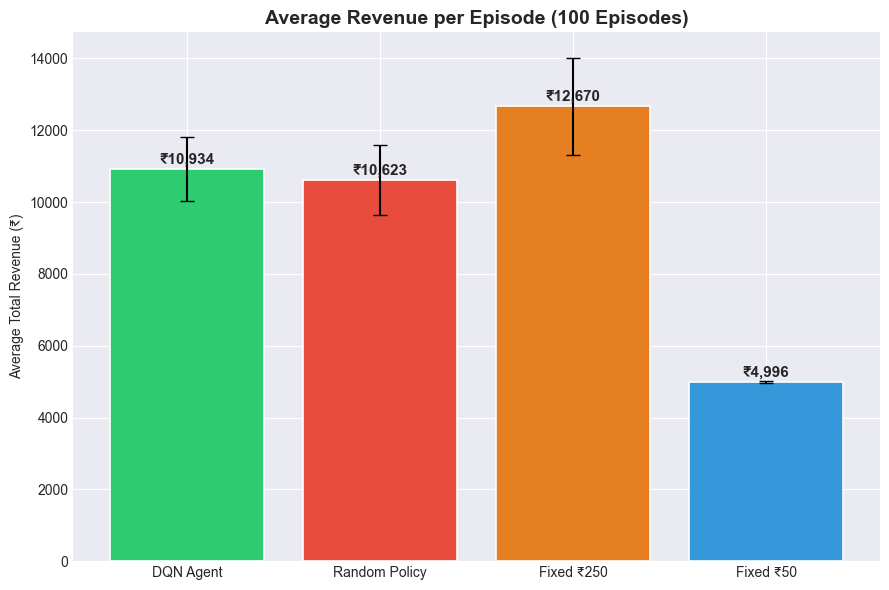

Saved: plots/avg_revenue_comparison.png


In [8]:
# Cell 8: Average Revenue Bar Chart

labels = [policy_labels[p] for p in policies]
means  = [avg_rewards[p]   for p in policies]
stds   = [np.std(revenues[p]) for p in policies]
cols   = [colors[p]        for p in policies]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(labels, means, color=cols,
              yerr=stds, capsize=5,
              edgecolor='white', linewidth=1.2)

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 150,
        f'₹{mean:,.0f}',
        ha='center', fontweight='bold', fontsize=11
    )

ax.set_title('Average Revenue per Episode (100 Episodes)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Average Total Revenue (₹)')
plt.tight_layout()
plt.savefig('plots/avg_revenue_comparison.png', dpi=150)
plt.show()
print("Saved: plots/avg_revenue_comparison.png")

In [9]:
# Cell 9: Revenue Improvement % vs Each Baseline

dqn_mean = avg_rewards['dqn']

print("=" * 55)
print("DQN REVENUE IMPROVEMENT VS BASELINES")
print("=" * 55)

improvement_rows = []
for p in ['random', 'fixed_high', 'fixed_low']:
    baseline_mean = avg_rewards[p]
    improvement   = (dqn_mean / baseline_mean - 1) * 100
    improvement_rows.append({
        'Baseline'        : policy_labels[p],
        'Baseline Revenue': f"₹{baseline_mean:,.2f}",
        'DQN Revenue'     : f"₹{dqn_mean:,.2f}",
        'Improvement %'   : f"+{improvement:.1f}%"
    })
    print(f"  vs {policy_labels[p]:<18}: "
          f"+{improvement:.1f}%")

print("=" * 55)

improvement_df = pd.DataFrame(improvement_rows)
print("\n")
print(improvement_df.to_string(index=False))

DQN REVENUE IMPROVEMENT VS BASELINES
  vs Random Policy     : +2.9%
  vs Fixed ₹250        : +-13.7%
  vs Fixed ₹50         : +118.8%


     Baseline Baseline Revenue DQN Revenue Improvement %
Random Policy       ₹10,623.00  ₹10,934.50         +2.9%
   Fixed ₹250       ₹12,670.00  ₹10,934.50       +-13.7%
    Fixed ₹50        ₹4,996.50  ₹10,934.50       +118.8%


In [10]:
# Cell 10: Complete Policy Evaluation Summary Table

summary_rows = []
for policy in policies:
    rev_list = revenues[policy]
    sold_list = [ep['rooms_sold']   for ep in results[policy]]
    unsold_list=[ep['rooms_unsold'] for ep in results[policy]]

    summary_rows.append({
        'Policy'             : policy_labels[policy],
        'Mean Revenue (₹)'   : round(np.mean(rev_list), 2),
        'Std (₹)'            : round(np.std(rev_list), 2),
        'Min (₹)'            : round(np.min(rev_list), 2),
        'Max (₹)'            : round(np.max(rev_list), 2),
        'Rooms Sold (avg)'   : round(np.mean(sold_list), 1),
        'Spoilage (avg)'     : round(np.mean(unsold_list), 1),
        'Cumulative (₹)'     : round(cumulative[policy][-1], 0)
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 70)
print("COMPLETE POLICY EVALUATION SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

best = summary_df.loc[
    summary_df['Mean Revenue (₹)'].idxmax(), 'Policy'
]
print(f"\nBest performing policy: {best}")
if best == 'DQN Agent':
    print("✓ DQN OUTPERFORMS ALL BASELINES")
else:
    print(f"✗ {best} beats DQN — further training needed")

# Save
summary_df.to_csv('policy_evaluation_summary.csv', index=False)
print("\nSaved: policy_evaluation_summary.csv")

COMPLETE POLICY EVALUATION SUMMARY
       Policy  Mean Revenue (₹)  Std (₹)  Min (₹)  Max (₹)  Rooms Sold (avg)  Spoilage (avg)  Cumulative (₹)
    DQN Agent           10934.5   889.71     8850    13250              81.3            18.7         1093450
Random Policy           10623.0   975.51     7950    12800              80.7            19.3         1062300
   Fixed ₹250           12670.0  1357.33     9500    17750              50.7            49.3         1267000
    Fixed ₹50            4996.5    26.70     4750     5000              99.9             0.1          499650

Best performing policy: Fixed ₹250
✗ Fixed ₹250 beats DQN — further training needed

Saved: policy_evaluation_summary.csv
